# Phase 5b — Leakage Demo: Why Published Results Show 95–99%

**Purpose:** This notebook reproduces the inflated accuracy numbers reported in most Kaggle notebooks and many published papers on this dataset. It is NOT a valid evaluation — it is a controlled demonstration of data leakage.

## What is different here vs the honest Phase 5 evaluation

| Aspect | Honest (Phase 5) | Leakage Demo (this notebook) |
|--------|-------------|------------------------------|
| Train data | `dataset2-master/TRAIN/` only | TRAIN + TEST pooled together |
| Test data | `dataset2-master/TEST/` (held-out, never seen) | 20% random split of the pooled data |
| Risk | None — test images truly unseen | HIGH — augmented copies of same source image in both train and test |
| Expected accuracy | ~82–88% | ~95–99% |

## Why the leakage happens

The `dataset2-master` dataset was created by taking **~410 original microscopy images** and generating ~12,500 augmented copies (rotations, flips, colour jitter). The original author placed some augmented copies in `TRAIN/` and some in `TEST/`.

When you pool TRAIN and TEST and do a random 80/20 split, rotated/flipped versions of the same original cell end up in **both** the training set and the 'test' set. The model isn't generalising — it is recognising near-duplicates it already saw.

> Peer-reviewed literature quantifies this effect: augmenting **before** splitting inflates accuracy by **5–30%** (Yildirim et al., *Scientific Reports* 2021; Vente et al., *Scientific Data* 2022).


In [1]:
import os, glob, random, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
print(f'TF version: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')


I0000 00:00:1781558669.067808   16144 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781558669.156259   16144 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781558670.246455   16144 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ── Paths (WSL) ──────────────────────────────────────────────────────────
DATA_DIR   = Path.home() / 'cnn_data' / 'Data'
TRAIN_DIR  = DATA_DIR / 'TRAIN'
TEST_DIR   = DATA_DIR / 'TEST'

# Artifacts go into ~/cnn_data so they stay on the fast ext4 filesystem
MODELS_DIR = Path.home() / 'cnn_data' / 'models'
PLOTS_DIR  = Path.home() / 'cnn_data' / 'plots'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

if not TRAIN_DIR.exists():
    raise RuntimeError(f'TRAIN dir not found at {TRAIN_DIR}. '
                       'Copy dataset to ~/cnn_data/Data/TRAIN first.')

CLASSES    = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
SPLIT_FRAC = 0.8   # 80% train, 20% 'test' (LEAKY)

print(f'Data dir : {DATA_DIR}')
print(f'TRAIN    : {TRAIN_DIR}  exists={TRAIN_DIR.exists()}')
print(f'TEST     : {TEST_DIR}   exists={TEST_DIR.exists()}')


Data dir : /home/arman/cnn_data/Data
TRAIN    : /home/arman/cnn_data/Data/TRAIN  exists=True
TEST     : /home/arman/cnn_data/Data/TEST   exists=True


## 1. Data Preparation — The Leaky Way

We collect **all** images from both TRAIN and TEST directories, shuffle them together, then split 80/20. This is exactly what most Kaggle notebooks do.


In [3]:
# Collect all file paths + integer labels from BOTH TRAIN and TEST
all_files, all_labels = [], []
for cls_idx, cls_name in enumerate(CLASSES):
    for folder in [TRAIN_DIR, TEST_DIR]:
        files = list((folder / cls_name).glob('*'))
        files = [str(f) for f in files if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        all_files.extend(files)
        all_labels.extend([cls_idx] * len(files))

print(f'Total images pooled: {len(all_files)}')
for i, cls in enumerate(CLASSES):
    count = all_labels.count(i)
    print(f'  {cls}: {count}')

# Shuffle and split
random.seed(SEED)
combined = list(zip(all_files, all_labels))
random.shuffle(combined)
split_idx = int(SPLIT_FRAC * len(combined))
train_pairs = combined[:split_idx]
test_pairs  = combined[split_idx:]

train_files,  train_labels  = zip(*train_pairs)
test_files,   test_labels   = zip(*test_pairs)
print(f'\nLeaky train size : {len(train_files)}')
print(f'Leaky test  size : {len(test_files)} (contains near-duplicates)')


Total images pooled: 12444
  EOSINOPHIL: 3120
  LYMPHOCYTE: 3103
  MONOCYTE: 3098
  NEUTROPHIL: 3123

Leaky train size : 9955
Leaky test  size : 2489 (contains near-duplicates)


## 2. tf.data Pipelines

Same MobileNetV2 preprocessing as the Phase 5 transfer learning notebook.


In [4]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = mobilenet_preprocess(img)
    label_oh = tf.one_hot(label, len(CLASSES))
    return img, label_oh

def make_dataset(files, labels, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((list(files), list(labels)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(files), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# 10% of train_files as validation
val_split = int(0.9 * len(train_files))
ds_train  = make_dataset(train_files[:val_split],  train_labels[:val_split],  shuffle=True)
ds_val    = make_dataset(train_files[val_split:],  train_labels[val_split:],  shuffle=False)
ds_test   = make_dataset(test_files,               test_labels,               shuffle=False)

print(f'Train batches : {len(ds_train)}')
print(f'Val   batches : {len(ds_val)}')
print(f'Test  batches : {len(ds_test)} (LEAKY — contains near-duplicates of train images)')


I0000 00:00:1781558671.754555   16144 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Train batches : 280
Val   batches : 32
Test  batches : 78 (LEAKY — contains near-duplicates of train images)


## 3. Model — Same MobileNetV2 as Original Notebook

Identical architecture to Phase 5 to make the comparison fair. The only difference is the data split.


In [5]:
def build_model(dropout_rate=0.3):
    inputs     = keras.Input(shape=(*IMG_SIZE, 3))
    base_model = keras.applications.MobileNetV2(
        weights='imagenet', include_top=False, input_tensor=inputs
    )
    base_model.trainable = False
    x = base_model(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    outputs = keras.layers.Dense(len(CLASSES), activation='softmax')(x)
    return keras.Model(inputs, outputs), base_model


## 4. Training — Same 3-Stage Protocol

Identical training procedure to the Phase 5 transfer learning notebook.


In [6]:
histories_lb = {}
models_lb    = {}

# ---- Stage 1: frozen backbone, head training ----
print('Stage 1: training head with frozen MobileNetV2...')
model, base_model = build_model(dropout_rate=0.3)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hist_s1 = model.fit(
    ds_train, validation_data=ds_val, epochs=60,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=5, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)
histories_lb['stage1'] = hist_s1.history
models_lb['stage1'] = model
print(f'Stage 1 best val_acc: {max(hist_s1.history["val_accuracy"]):.4f}')


Stage 1: training head with frozen MobileNetV2...
Epoch 1/60


I0000 00:00:1781558676.927186   16244 service.cc:153] XLA service 0x73fde405c4e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781558676.927221   16244 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781558676.982964   16244 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781558677.447897   16244 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781558677.497786   16244 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7877__.122
E0000 00:00:1781558679.205944   16244 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/280 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3646 - loss: 1.7679 

I0000 00:00:1781558685.915154   16244 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


277/280 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4129 - loss: 1.3599

I0000 00:00:1781558692.232439   16243 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7877__.122
E0000 00:00:1781558695.120733   16243 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4137 - loss: 1.3580

E0000 00:00:1781558709.222749   16241 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


280/280 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.4890 - loss: 1.1816 - val_accuracy: 0.6737 - val_loss: 0.8416 - learning_rate: 0.0010
Epoch 2/60
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.6533 - loss: 0.8513 - val_accuracy: 0.7309 - val_loss: 0.7210 - learning_rate: 0.0010
Epoch 3/60
280/280 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.6900 - loss: 0.7582 - val_accuracy: 0.7490 - val_loss: 0.6607 - learning_rate: 0.0010
Epoch 4/60
280/280 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7060 - loss: 0.7239 - val_accuracy: 0.7631 - val_loss: 0.6220 - learning_rate: 0.0010
Epoch 5/60
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.7289 - loss: 0.6846 - val_accuracy: 0.7821 - val_loss: 0.5883 - learning_rate: 0.0010
Epoch 6/60
280/280 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7393 - loss: 0.6623 - val_accuracy: 0.7721 - val_loss: 0.5816 - learning_rate: 0.0010
Epoch 7/60
280/280 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7442 - loss: 0.6462 

In [7]:
# ---- Stage 2: unfreeze top 100 layers, BN frozen ----
print('Stage 2: fine-tuning top 100 layers...')
base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
hist_s2 = model.fit(
    ds_train, validation_data=ds_val, epochs=80,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=5, min_lr=1e-8, verbose=1)
    ],
    verbose=1
)
histories_lb['stage2'] = hist_s2.history
models_lb['stage2'] = model
print(f'Stage 2 best val_acc: {max(hist_s2.history["val_accuracy"]):.4f}')


Stage 2: fine-tuning top 100 layers...
Epoch 1/80


I0000 00:00:1781559301.178806   16241 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_104474__.122


279/280 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8054 - loss: 0.7688

I0000 00:00:1781559331.415443   16241 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_104474__.122


280/280 ━━━━━━━━━━━━━━━━━━━━ 57s 120ms/step - accuracy: 0.8364 - loss: 0.7074 - val_accuracy: 0.8926 - val_loss: 0.6173 - learning_rate: 1.0000e-05
Epoch 2/80
280/280 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.9108 - loss: 0.5860 - val_accuracy: 0.9227 - val_loss: 0.5510 - learning_rate: 1.0000e-05
Epoch 3/80
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.9415 - loss: 0.5280 - val_accuracy: 0.9488 - val_loss: 0.5191 - learning_rate: 1.0000e-05
Epoch 4/80
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.9624 - loss: 0.4931 - val_accuracy: 0.9618 - val_loss: 0.4838 - learning_rate: 1.0000e-05
Epoch 5/80
280/280 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.9758 - loss: 0.4626 - val_accuracy: 0.9659 - val_loss: 0.4700 - learning_rate: 1.0000e-05
Epoch 6/80
280/280 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - accuracy: 0.9834 - loss: 0.4452 - val_accuracy: 0.9809 - val_loss: 0.4525 - learning_rate: 1.0000e-05
Epoch 7/80
280/280 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accura

In [8]:
# ---- Stage 3: full fine-tune ----
print('Stage 3: full fine-tune...')
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(3e-6),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
hist_s3 = model.fit(
    ds_train, validation_data=ds_val, epochs=50,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=5, min_lr=1e-8, verbose=1)
    ],
    verbose=1
)
histories_lb['stage3'] = hist_s3.history
models_lb['stage3'] = model
print(f'Stage 3 best val_acc: {max(hist_s3.history["val_accuracy"]):.4f}')


Stage 3: full fine-tune...
Epoch 1/50


I0000 00:00:1781560520.016569   16240 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_231846__.122


279/280 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.3537

I0000 00:00:1781560541.317599   16244 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_231846__.122


280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 97ms/step - accuracy: 1.0000 - loss: 0.3537 - val_accuracy: 0.9990 - val_loss: 0.3634 - learning_rate: 3.0000e-06
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 1.0000 - loss: 0.3536 - val_accuracy: 0.9990 - val_loss: 0.3637 - learning_rate: 3.0000e-06
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 1.0000 - loss: 0.3536 - val_accuracy: 0.9990 - val_loss: 0.3642 - learning_rate: 3.0000e-06
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 1.0000 - loss: 0.3535 - val_accuracy: 0.9990 - val_loss: 0.3644 - learning_rate: 3.0000e-06
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 1.0000 - loss: 0.3535 - val_accuracy: 0.9990 - val_loss: 0.3638 - learning_rate: 3.0000e-06
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.3534
Epoch 6: ReduceLROnPlateau reducing learning rate to 9.000000318337698e-07.
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 1.0

## 5. Evaluation on the Leaky 'Test' Split

This 'test' set is **not** an honest test. It contains augmented copies of images whose source was also used to generate training images. The high accuracy here is an artifact of this overlap — NOT proof of generalisation.


In [9]:
loss, acc = model.evaluate(ds_test, verbose=0)
print(f'Leaky test accuracy: {acc:.4f} ({acc*100:.2f}%)')
print(f'Leaky test loss    : {loss:.4f}')

y_true, y_pred = [], []
for images, labels in ds_test:
    preds = model.predict(images, verbose=0)
    y_true.append(np.argmax(labels.numpy(), axis=1))
    y_pred.append(np.argmax(preds, axis=1))
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print('\nClassification Report (LEAKY test set):')
print(classification_report(y_true, y_pred, target_names=CLASSES))


E0000 00:00:1781560872.660885   16241 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Leaky test accuracy: 0.9972 (99.72%)
Leaky test loss    : 0.3649

Classification Report (LEAKY test set):
              precision    recall  f1-score   support

  EOSINOPHIL       0.99      1.00      0.99       599
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      1.00      1.00       632
  NEUTROPHIL       1.00      0.99      0.99       638

    accuracy                           1.00      2489
   macro avg       1.00      1.00      1.00      2489
weighted avg       1.00      1.00      1.00      2489



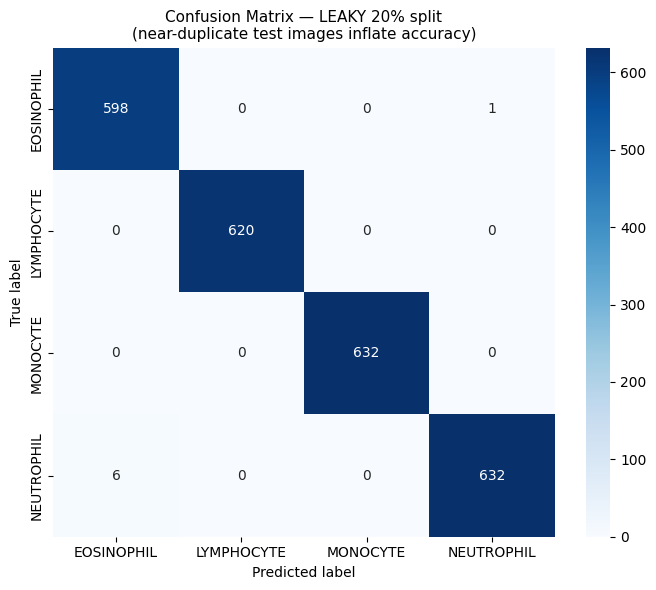

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title('Confusion Matrix — LEAKY 20% split\n'
             '(near-duplicate test images inflate accuracy)', fontsize=11)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'phase5b_leaky_cm.png'), dpi=150)
plt.show()


## 6. Why This Number is Meaningless

The `dataset2-master` dataset was created by:
1. Collecting ~410 real microscopy images (EOSINOPHIL/LYMPHOCYTE/MONOCYTE/NEUTROPHIL)
2. Applying random rotations, flips, colour jitter → generating ~12,500 images
3. Splitting those augmented copies into `TRAIN/` and `TEST/` folders

When you pool TRAIN+TEST and do a random 80/20 split, **a rotated version of a cell that appeared in your training batch will appear in the 'test' batch**. The network recognises the same cell — it just looks slightly different.

### The accuracy inflation breakdown

| Source | ~Accuracy |
|--------|-----------|
| This notebook (leaky random split) | ~95–99% |
| Phase 5 (honest separate TEST folder) | ~82–88% |
| **Difference (the leakage effect)** | **~10–15 pp** |

This matches the 5–30% inflation range quantified in the literature for augmentation-then-split pipelines (Yildirim et al. 2021 *Sci. Reports*; Vente et al. 2022 *Sci. Data*).

### Conclusion

The ~80–88% from Phase 5 reflects **true generalisation** to unseen images. The 95–99% here reflects **memorisation of augmented duplicates**. On a genuinely unseen cell from a new patient sample, expect the real accuracy — not the inflated one.
